# Demonstration of New Capabilities

We generate a new wavefront using the sase_pulse source, located in the new 'Source' class

In [23]:
from copy import deepcopy

from matplotlib import pyplot as plt 

from wpg.beamline import Beamline
from wpg.optical_elements import Drift, Aperture
from wpg.wpg_uti_oe import propagation_parameters
from wpg.wpg_uti_wf import plot_intensity_map

In [21]:
import numpy as np
from wpg.source import sase_pulse

## define the spatial/temporal mesh
x = y = np.linspace(-300e-06, 300e-06, 1024)
t = np.linspace(-25e-15, 25e-15, 2)

def get_source():
    ## define the pulse
    wfr = sase_pulse(x = x,
                    y = y,
                    t = t,
                    photon_energy = 10e3,
                    pulse_energy = 1e-03,
                    pulse_duration = 15e-15,
                    bandwidth = 1e-12,
                    sigma = 25e-06,
                    div = 50e-06,
                    x0 = 0.0,
                    y0 = 0.0,
                    t0 = 0.0,
                    theta_x = 0.0,
                    theta_y = 0.0,
                    domain = 'freq'
    )
    return wfr

R-space
(1024,) (1024,)
FWHM in x = 2.032e-03 m.
FWHM in y = 2.032e-03 m.


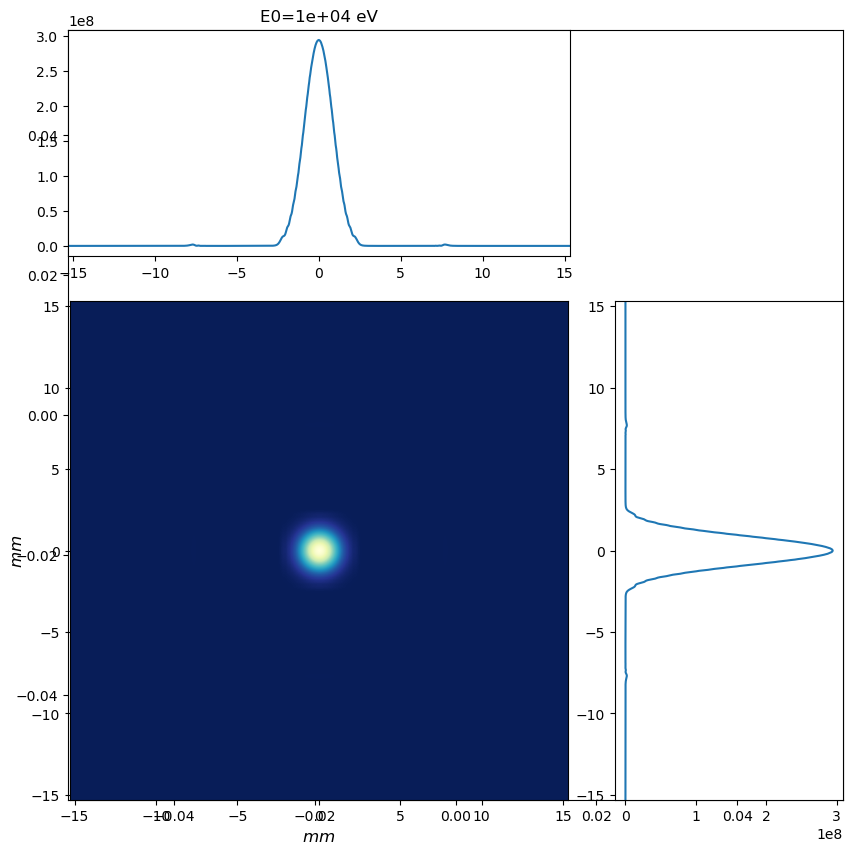

In [22]:
### get source
wfr = get_source()

### define optical elements
D = Drift(50)
D.name = "drift1"

bl = Beamline()
bl.append(D, propagation_parameters(1,1,1,1, mode = 'fraunhofer'))
bl.propagate(wfr)
plot_intensity_map(wfr)



In [4]:
bl.index

{'drift1': 0}

In [5]:
bl.get_element_properties('drift1')

{'L': 50, 'treat': 0, 'name': 'drift1'}

In [6]:
bl.edit_element_property('drift1', 'L', 45)
bl.get_element_properties('drift1')

{'L': 45, 'treat': 0, 'name': 'drift1'}

Beam Width: 866.28 $\mu$m


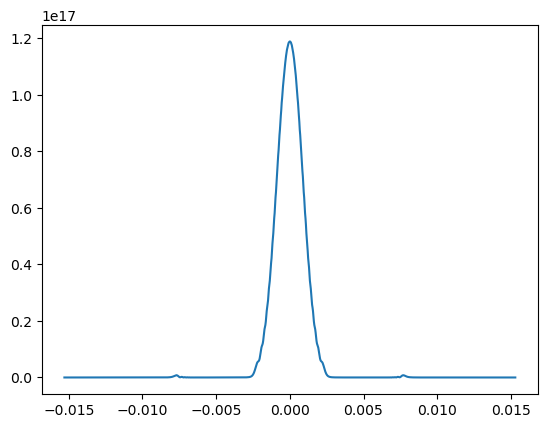

In [20]:
from wpg.wpg_uti_math import gaussian
from matplotlib import pyplot as plt

axis = 'x'

plt.plot(wfr.get_axis(axis), wfr.get_profile(axis))
bw = wfr.get_beam_width(axis)[0]
print(r"Beam Width: {:.2f} $\mu$m".format(bw*1e6))


In [16]:
bw

(0.0008662840211326312, -5.406124879566515e-10, 1.1880269300279752e+17)